In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [2]:
from sentence_transformers import SentenceTransformer
# 1. Load a pretrained Sentence Transformer model
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

c:\Users\lwp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6335.16it/s]


In [3]:
import kagglehub

dataset_handle = "omkarborikar/top-10000-popular-movies"
dataset_file = "Top_10000_Movies.csv"
dataset_path = kagglehub.dataset_download("omkarborikar/top-10000-popular-movies")

In [ ]:
import pandas as pd
df = pd.read_csv(f"{dataset_path}/Top_10000_Movies.csv",
    on_bad_lines='skip',  # skip corrupted rows
    engine='python',      # more tolerant parser
    encoding_errors='ignore')


In [41]:
pd.to_datetime(df.query('original_title == "Monster"')['release_date']).dt.year

df['display_title'] = df['original_title'] + " (" + df['release_date'].apply(lambda x: pd.to_datetime(x).year).astype('Int64').astype(str) + ")"
df['display_title']

0        Venom: Let There Be Carnage (2021)
1                           Eternals (2021)
2                               Dune (2021)
3                    Army of Thieves (2021)
4                           Free Guy (2021)
                        ...                
10009                A Grand Day Out (1990)
10010                    El cantante (2006)
10011                 How I Live Now (2013)
10012                           Once (2007)
10013                Manhattan Night (2016)
Name: display_title, Length: 9900, dtype: str

In [24]:
df.head(10).overview

0    After finding a host body in investigative rep...
1    The Eternals are a team of ancient aliens who ...
2    Paul Atreides, a brilliant and gifted young ma...
3    A mysterious woman recruits bank teller Ludwig...
4    A bank teller called Guy realizes he is a back...
5    In her turbulent life as a professional assass...
6    Investigative journalist Eddie Brock attempts ...
7    Minutes after Laurie Strode, her daughter Kare...
8    When something horrible happens to the only su...
9    A seemingly cold-blooded hitman is assigned to...
Name: overview, dtype: str

In [33]:
# Use the overview column for embedding
df = df[df['overview'].notna()]
# Generate sentence embeddings for all movie overviews
embeddings = model.encode(df['overview'].tolist())

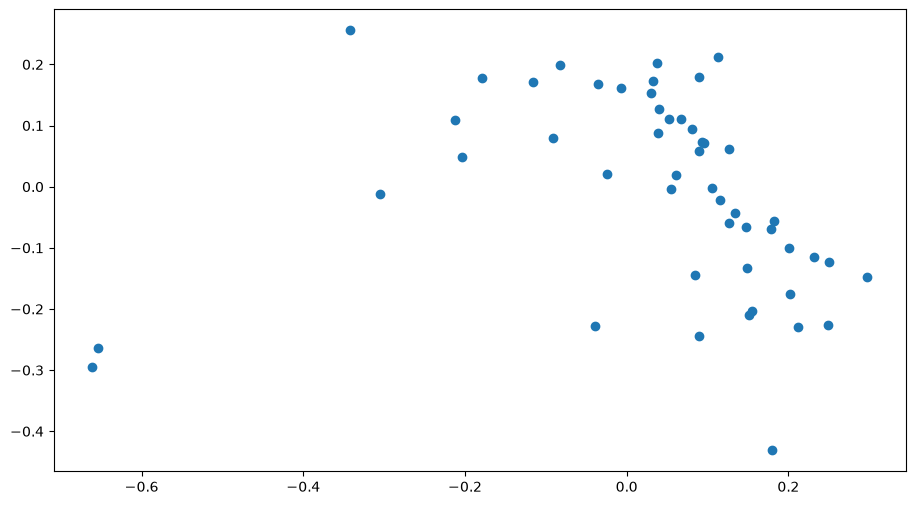

In [8]:
pca = PCA(n_components=2)
embd_2d = pca.fit_transform(embeddings)
embd_2d=embd_2d[:50]
plt.figure(figsize=(11,6))
plt.scatter(embd_2d[:, 0], embd_2d[:, 1])

In [9]:
# Train KNN model
nn = NearestNeighbors(n_neighbors=10)
nn.fit(embeddings)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'eu...an'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


Query:
Japan big monster

Nearest neighbors by distance:
0.8389 - Godzilla (2014)
0.8389 - V.C. Andrews' Pearl in the Mist (2021)
0.8827 - Godzilla: King of the Monsters (2019)
0.9333 - Freier Fall (2013)
0.9342 - V/H/S (2012)
0.9365 - Rare Exports (2010)
0.9365 - Arctic (2018)
0.9511 - 악마를 보았다 (2010)
0.9514 - El Amarre (2021)
0.9638 - Godzilla vs. Kong (2021)


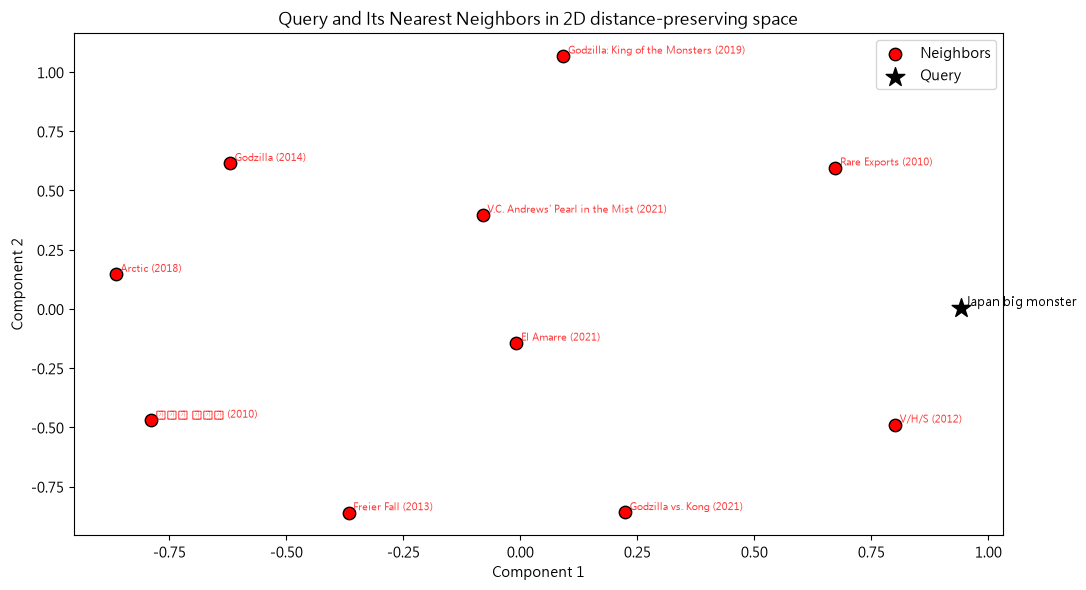

In [51]:
# Test
query = "Japan big monster"

emb = model.encode([query])
distances, neighbors = nn.kneighbors(emb, return_distance=True)
print('Query:')
print(query)
print('\nNearest neighbors by distance:')
for dist, idx in zip(distances[0], neighbors[0]):
    print(f"{dist:.4f} - {df.loc[idx, 'display_title']}")

# Plot the query and its neighbors in 2D distance-preserving space
from sklearn.manifold import MDS
query_emb = emb
neighbor_indices = neighbors[0].tolist()
selected_embeddings = np.vstack([query_emb, embeddings[neighbor_indices]])
mds = MDS(n_components=2, metric_mds=True, init='classical_mds', random_state=42)
selected_2d = mds.fit_transform(selected_embeddings)
query_2d = selected_2d[0]
neighbor_points = selected_2d[1:]

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
plt.figure(figsize=(11,6))
if len(neighbor_points) > 0:
    plt.scatter(neighbor_points[:, 0], neighbor_points[:, 1],
                color='red', edgecolors='k', s=80, label='Neighbors')
plt.scatter(query_2d[0], query_2d[1], color='black', marker='*', s=200, label='Query')
for idx, pt in zip(neighbor_indices, neighbor_points):
    plt.text(pt[0] + 0.01, pt[1] + 0.01, df.loc[idx, 'display_title'], fontsize=7, color='red', alpha=0.8)
plt.text(query_2d[0] + 0.01, query_2d[1] + 0.01, query, fontsize=9, color='black', weight='bold')
plt.title('Query and Its Nearest Neighbors in 2D distance-preserving space')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()
plt.tight_layout()